**Netflix Content Strategy Analyzer: Insights into Global Streaming Trends**

In [149]:
import pandas as pd
import kagglehub
import matplotlib as plt


In [150]:
# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [151]:
df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

In [152]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [153]:
df.shape

(8807, 12)

In [154]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [155]:

df[df.duplicated()].sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [156]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


# **Data cleaning**

# Handling null, missing and inconsistent categories

In [157]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [158]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [159]:
df = df.dropna(subset=['rating'])
df = df.dropna(subset=['duration'])
df = df.dropna(subset=['date_added'])

In [160]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**Handle Inconsistent Columns**

In [161]:
df=df.rename(columns={"listed_in":"genre"})

In [162]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **NORMALIZATION**

In [163]:
# df['genre'] = df['genre'].str.split(',')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [164]:

df = df.explode('genre')
df['genre'] = df['genre'].str.strip()
df['genre'] = df['genre'].str.title()

In [165]:
#remove any leading or trailing spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [166]:
#to lower case
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [167]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')



/tmp/ipykernel_247/51712857.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')


In [168]:
df['duration_minutes'] = df['duration'].where(df['type'] == 'movie')
df['seasons'] = df['duration'].where(df['type'] == 'tv show')


In [169]:
df['seasons'] = df['seasons'].str.extract(r'(\d+)').astype(float)
df['duration_minutes'] = df['duration_minutes'].str.extract(r'(\d+)').astype(float)

In [170]:
df['seasons'] = df['seasons'].fillna('Unknown')
df['duration_minutes'] = df['duration_minutes'].fillna('Unknown')

In [171]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,duration_minutes,seasons
0,s1,movie,dick johnson is dead,kirsten johnson,unknown,united states,2021-09-25,2020,pg-13,90 min,documentaries,"as her father nears the end of his life, filmm...",90.0,Unknown
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24,2021,tv-ma,2 seasons,"international tv shows, tv dramas, tv mysteries","after crossing paths at a party, a cape town t...",Unknown,2.0
2,s3,tv show,ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",unknown,2021-09-24,2021,tv-ma,1 season,"crime tv shows, international tv shows, tv act...",to protect his family from a powerful drug lor...,Unknown,1.0
3,s4,tv show,jailbirds new orleans,unknown,unknown,unknown,2021-09-24,2021,tv-ma,1 season,"docuseries, reality tv","feuds, flirtations and toilet talk go down amo...",Unknown,1.0
4,s5,tv show,kota factory,unknown,"mayur more, jitendra kumar, ranjan raj, alam k...",india,2021-09-24,2021,tv-ma,2 seasons,"international tv shows, romantic tv shows, tv ...",in a city of coaching centers known to train i...,Unknown,2.0


In [172]:
df = df.dropna(subset=['genre'])
df = df.reset_index(drop=True)


In [173]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


# Analyze Netflix content growth over time.

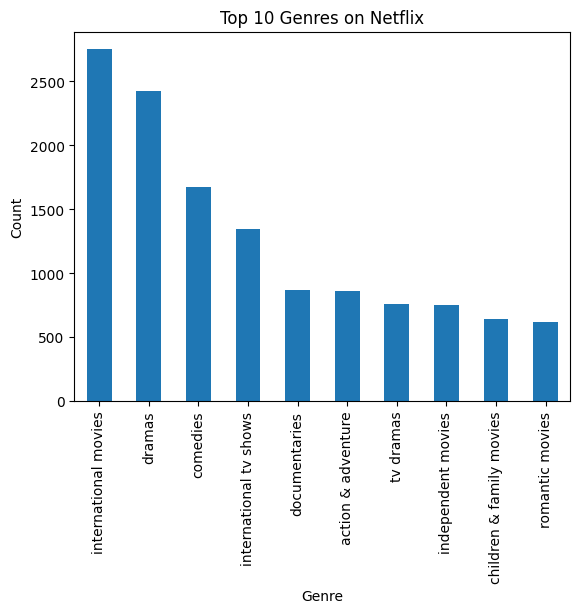

In [174]:
import matplotlib.pyplot as plt

genre = df['genre'].str.split(',', expand=True).stack().str.strip()

genre.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

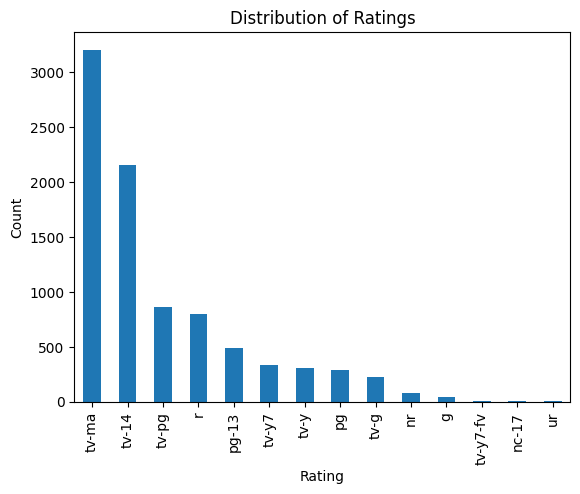

In [175]:
df['rating'].value_counts().plot(kind='bar')

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [176]:
df['country'].str.contains(',').sum()

np.int64(1320)

In [177]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


<Axes: title={'center': 'Netflix Content Growth Over Time'}, xlabel='year_added'>

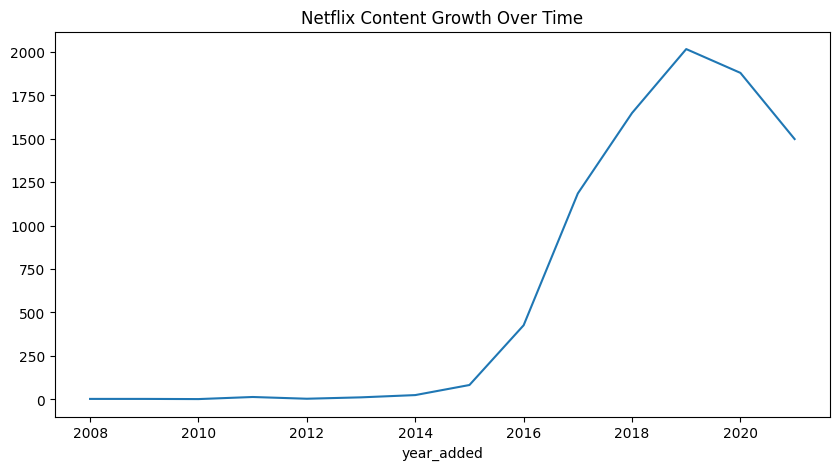

In [178]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
content_growth = df.groupby('year_added')['show_id'].count()

content_growth.plot(kind='line', figsize=(10,5), title="Netflix Content Growth Over Time")

<Axes: title={'center': 'Distribution of Content Type'}, xlabel='type'>

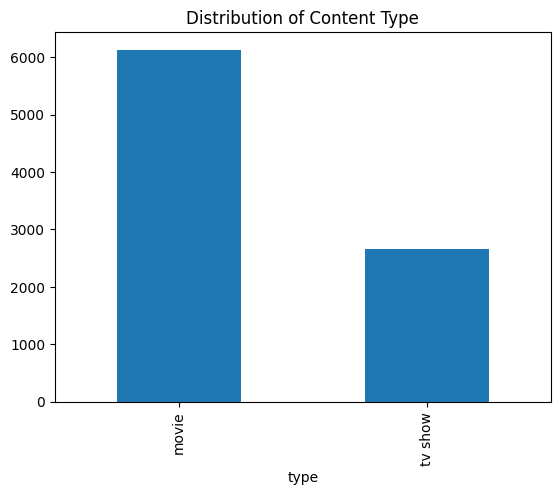

In [179]:
df['type'].value_counts().plot(kind='bar', title='Distribution of Content Type')

<Axes: title={'center': 'Top Content Producing Countries'}, xlabel='country'>

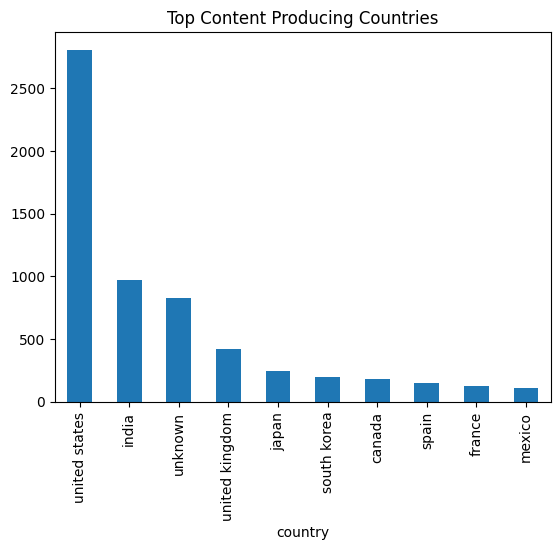

In [180]:
countries=df['country']

top_countries = countries.value_counts().head(10)

top_countries.plot(kind='bar', title='Top Content Producing Countries')